In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/Student Social Media And Mental Health Impact.csv')

In [3]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [4]:
df.shape

(5000, 13)

## 1. Missing values — full audit
Check every column, not just a few.

In [5]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

## 2. Duplicates

In [6]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
df.shape

Duplicate rows: 2


(4998, 13)

## 3. Categorical consistency
Look for stray whitespace, casing issues, or unexpected categories.

In [7]:
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print('Categorical:', cat_cols)
print('Numeric:', num_cols)

Categorical: ['Gender', 'Country', 'Academic_Level', 'Most_Used_Platform', 'Purpose_Of_Use', 'Stress_Level']
Numeric: ['Age', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']


In [8]:
for c in cat_cols:
    print(f'{c}: {sorted(df[c].unique())}')

Gender: ['Female', 'Male']
Country: ['Afghanistan', 'Albania', 'Andorra', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Bhutan', 'Bolivia', 'Bosnia', 'Brazil', 'Bulgaria', 'Canada', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Ecuador', 'Egypt', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Hong Kong', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iraq', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kenya', 'Kosovo', 'Kuwait', 'Kyrgyzstan', 'Latvia', 'Lebanon', 'Liechtenstein', 'Lithuania', 'Luxembourg', 'Malaysia', 'Maldives', 'Malta', 'Mexico', 'Moldova', 'Monaco', 'Montenegro', 'Morocco', 'Nepal', 'Netherlands', 'New Zealand', 'Nigeria', 'North Macedonia', 'Norway', 'Oman', 'Other', 'Pakistan', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russia', 'San Marino', '

In [9]:
# Trim stray whitespace and collapse repeated spaces
for c in cat_cols:
    df[c] = df[c].str.strip().str.replace(r'\s+', ' ', regex=True)

## 4. Numeric ranges & outliers
Verify values are physically plausible and check for outliers.

In [10]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,4998.0,20.822129,1.736774,18.0,19.0,21.0,22.0,24.0
Avg_Daily_Usage_Hours,4998.0,5.078491,1.654097,1.0,3.8,5.0,6.3,8.8
Daily_Unlocks,4998.0,171.455582,42.859829,62.0,140.0,171.0,204.0,273.0
Study_Hours,4998.0,3.008403,1.636831,0.3,1.5,2.8,4.2,8.3
Physical_Activity_Hours,4998.0,1.750760,0.668406,-0.4,1.3,1.7,2.2,4.1
Sleep_Hours_Per_Night,4998.0,6.634654,1.221561,3.6,5.6,6.6,7.5,9.9
Mental_Health_Score,4998.0,6.231152,1.278476,3.6,5.1,6.1,7.1,9.4


In [11]:
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[c] < lo) | (df[c] > hi)).sum()
    print(f'{c:28s} outliers: {n_out:4d}  (IQR bounds: {lo:.2f}, {hi:.2f})')

Age                          outliers:    0  (IQR bounds: 14.50, 26.50)
Avg_Daily_Usage_Hours        outliers:    0  (IQR bounds: 0.05, 10.05)
Daily_Unlocks                outliers:    0  (IQR bounds: 44.00, 300.00)
Study_Hours                  outliers:    2  (IQR bounds: -2.55, 8.25)


Physical_Activity_Hours      outliers:   22  (IQR bounds: -0.05, 3.55)
Sleep_Hours_Per_Night        outliers:    0  (IQR bounds: 2.75, 10.35)
Mental_Health_Score          outliers:    0  (IQR bounds: 2.10, 10.10)


/tmp/ipykernel_50307/2494307555.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[c], vert=False)
/tmp/ipykernel_50307/2494307555.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[c], vert=False)
/tmp/ipykernel_50307/2494307555.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[c], vert=False)
/tmp/ipykernel_50307/2494307555.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(df[c], vert=False)
/tmp/ipykernel_50307/2494307555.py:3: MatplotlibDeprecationWarning: vert: bool was deprecate

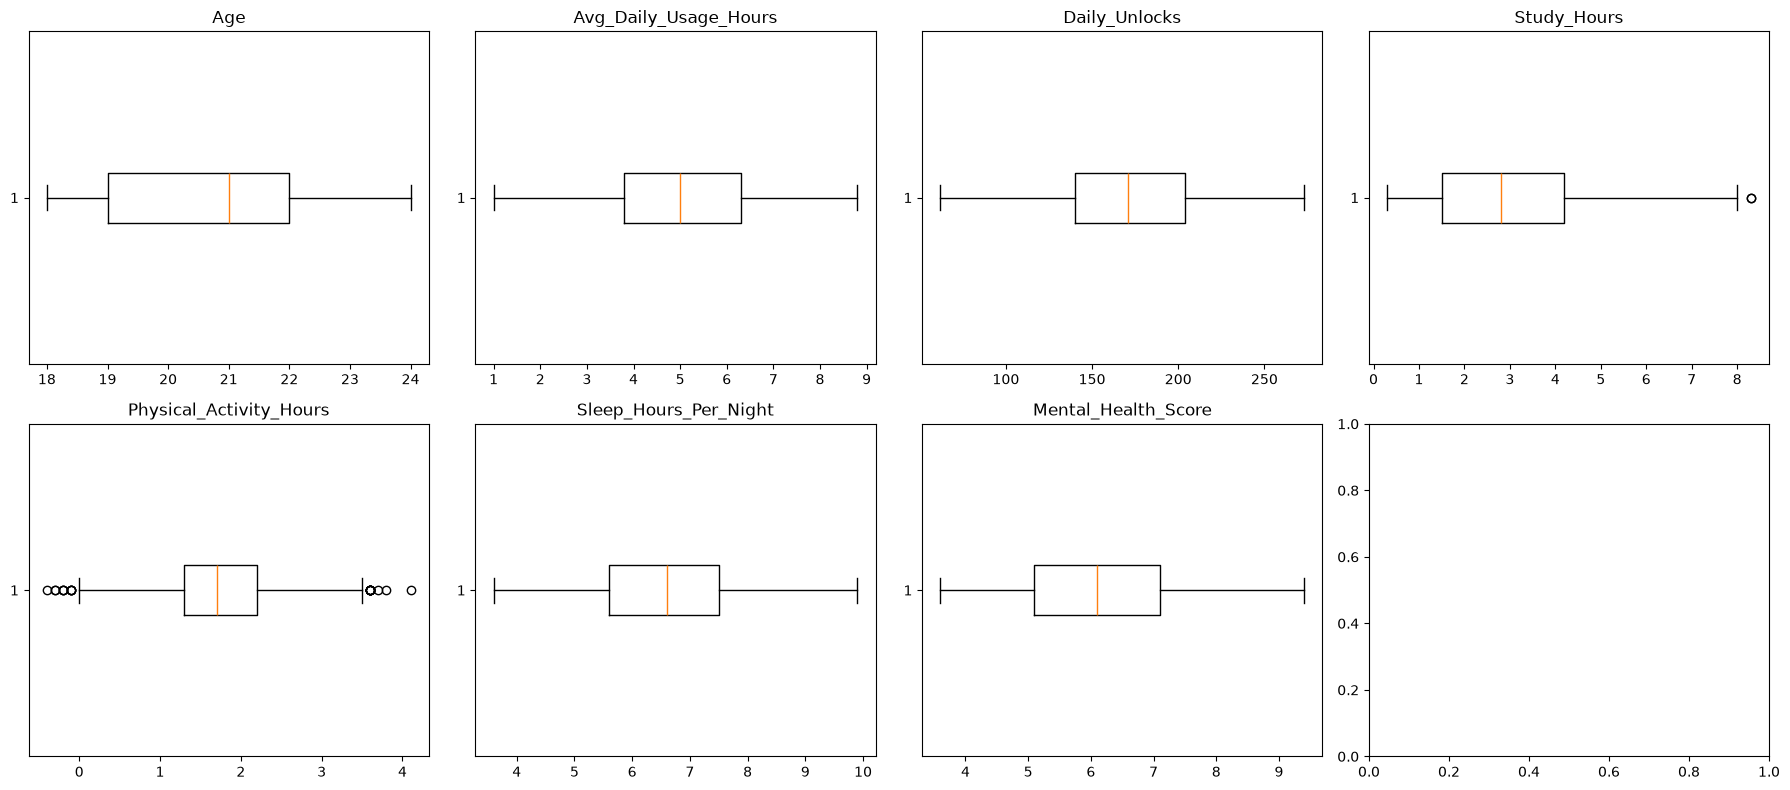

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.flat, num_cols):
    ax.boxplot(df[c], vert=False)
    ax.set_title(c)
plt.tight_layout()
plt.show()

## 5. Fix invalid values
`Physical_Activity_Hours` has negative values — hours of activity can never be negative,
so clip them to 0.

In [13]:
neg = (df['Physical_Activity_Hours'] < 0).sum()
print(f'Rows with negative Physical_Activity_Hours: {neg}')
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)
print('Fixed. New min:', df['Physical_Activity_Hours'].min())

Rows with negative Physical_Activity_Hours: 10
Fixed. New min: 0.0


## 6. Final validation
Sanity-check every numeric column against plausible bounds before saving.

In [14]:
assert df['Age'].between(15, 30).all()
assert df['Avg_Daily_Usage_Hours'].between(0, 24).all()
assert df['Daily_Unlocks'].between(0, 2000).all()
assert df['Study_Hours'].between(0, 24).all()
assert df['Physical_Activity_Hours'].between(0, 24).all()
assert df['Sleep_Hours_Per_Night'].between(0, 24).all()
assert df['Mental_Health_Score'].between(0, 10).all()
assert set(df['Stress_Level'].unique()) == {'Low', 'Medium', 'High', 'Very High'}
assert df.isnull().sum().sum() == 0
assert df.duplicated().sum() == 0
print('All validation checks passed')

All validation checks passed


## 7. Save clean dataset

In [15]:
print('Final shape:', df.shape)
df.head()

Final shape: (4998, 13)


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [16]:
df.to_csv('../data/processed/student_social_media_mental_health_clean.csv', index=False)
print('Saved ../data/processed/student_social_media_mental_health_clean.csv')

Saved ../data/processed/student_social_media_mental_health_clean.csv
